# Logistic Regression

In [1]:
# importiamo i pacchetti necessari
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.class_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 0

## Studio binario

Tramite questo studio di classificazione vogliamo essere in grado di effettuare previsioni sull'inquinamento dell'aria.\
Per sfruttare al massimo le conoscenze sviluppate in classe, scriviamo inizialmente il problema come un preblema di carattere binario. In particolare, etichettiamo come 1 = 'ok' tutti i punti con EAQI 'good' o 'fair' (AQI < 40), mentre chiamiamo 0 = 'not ok' i restanti punti con EAQI 'moderate', 'poor' o 'very poor'. Data una certa ora, cerchiamo quindi di prevedere se la qualità dell'aria sarà 'ok' o 'not ok' sulla base delle rilevazioni nelle ore a questa precedenti.

Costruiamo quindi il dataframe inserendo le ore precedenti a quella di target come specificato sopra.

Seppure la colonna 'winds_spd' sia molto correlata con gli inquinanti, contenendo diversi NaN, scegliamo per il momento di escluderla. L'influenza di questa feature sulle previsioni è approfondita nel notebook di appendice

In [3]:
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

# droppiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
binary_class_df.dropna(inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,monday,tuesday,wednesday,...,NO2_2,AQI_2,power_area_50_2,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,target
0,1,0,0,0,0,0,0,0,0,0,...,17.0,22.0,14.669913,19.0,19.0,24.0,17.861264,10.950,0.0,1
1,1,0,0,0,0,0,0,0,0,0,...,18.0,26.0,16.969367,20.0,17.0,22.0,14.669913,11.000,0.0,1
2,1,0,0,0,0,0,0,0,0,0,...,16.0,26.0,15.329278,21.0,18.0,26.0,16.969367,10.925,0.0,1
3,1,0,0,0,0,0,0,0,0,0,...,16.0,32.0,17.519438,19.0,16.0,26.0,15.329278,10.950,0.0,1
4,1,0,0,0,0,0,0,0,0,0,...,15.0,22.0,17.446178,24.0,16.0,32.0,17.519438,11.550,0.0,1


### Train, Valid, Test split
Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). Utilizziamo la cross-validation k-fold già implementata in LogisticRegressionCV. Introduciamo valid come insieme su cui scegliere il threshold più adatto per la logistic regression. Dopo aver scelto quest'ultima, rialleniamo il modello su train + valid e lo testiamo su test.

In [4]:
feature_cols = binary_class_df.columns.difference(['target'])

# creo train, valid e test
X_train, X_temp, y_train, y_temp = train_test_split(binary_class_df[feature_cols], binary_class_df['target'], test_size=0.3, random_state=seed)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

# riscaliamo le feature numeriche, mettendo la media a 0 e la deviazione std a 1
station_cols = [col for col in X_train.columns if col.startswith('station_')]
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] + station_cols
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_valid = scaler.transform(X_valid[num_features])

scaled_X_train = X_train.copy()
scaled_X_valid = X_valid.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_valid[num_features] = scaled_num_X_valid

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,PM10_3,day,...,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,sunday,temperature,thursday,tuesday,wednesday
1316,0.490002,0.307837,0.119001,-0.520774,-0.522160,-0.558751,0.068491,0.118310,0.407231,58,...,0,0,0,0,0,0,-0.639428,0,0,0
8848,-0.714854,-1.037990,-1.179124,-0.087800,-0.555498,-0.758696,-0.632505,-0.682923,-0.730055,26,...,0,0,0,0,1,0,-0.220294,0,1,0
4308,-0.784365,-0.794349,-0.831412,-1.086970,-1.122256,-1.091938,-0.632505,-0.632846,-0.631160,11,...,0,1,0,0,0,0,1.350060,0,0,0
2138,-0.297789,-0.365077,-0.390977,-1.253498,-1.255610,-1.258558,-0.932932,-0.983386,-0.977291,37,...,0,0,0,0,0,0,-0.913262,0,0,0
7870,1.416814,0.307837,0.211724,1.577482,0.711371,0.840862,0.418989,0.018156,0.011653,44,...,0,0,0,1,0,0,-0.645017,0,0,0


### Allenamento modello

In [5]:
# inizializziamo il classificatore
LR_cv = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=10,                              # cv = n => n-fold cross validation
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=5000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',            # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed                   # per la riproducibilità dei risultati
)

In [6]:
# alleniamo il modello sul nostro insieme di training
LR_cv.fit(scaled_X_train,y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for t

### Studio importanza features
Quali sono le features più importanti?

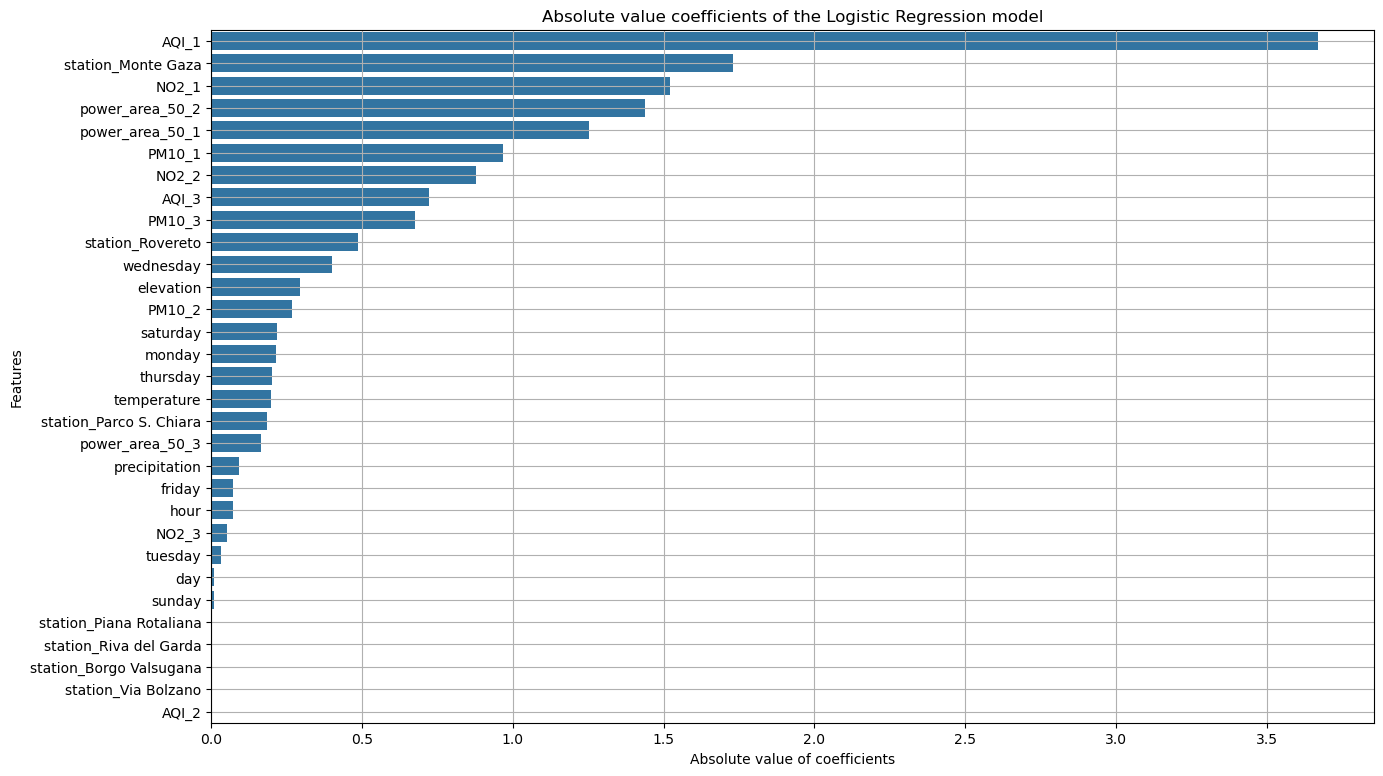

In [7]:
coefs_df = pd.DataFrame(LR_cv.coef_.T,columns=['coefficients'],index=feature_cols)

fig = plt.figure(figsize=(15,9))

orded_coefs_df = coefs_df.abs().sort_values('coefficients', ascending=False)
sns.barplot(x=orded_coefs_df['coefficients'], y=orded_coefs_df.index)
plt.title('Absolute value coefficients of the Logistic Regression model')
plt.xlabel('Absolute value of coefficients')
plt.ylabel('Features')
plt.grid()

plt.show()

Come ci si poteva aspettare, il valore di AQI un'ora prima è molto importante per predire se la qualità dell'aria sarà 'ok' o 'not ok' l'ora dopo. Anche i dati sui consumi elettrici una e due ore prima sono molto rilevanti, addirittura più rilevanti dei dati su 'PM10' e 'NO2'. Probabilmente questo è dovuto al fatto che l'AQI, e quindi la qualità dell'aria, è una misura di massimo tra gli indici di ciascun inquinante. Pertanto spesso i dati degli altri inquinanti sono rilevanti solo in quanto sono correlati loro stessi con gli inquinanti che determinano l'AQI.

Come aspettato, Riva del Garda non contribuisce, visto che i suoi dati vengono rimossi dal momento in cui si considerano i consumi elettrici.

Monte Gaza sembra invece una feature particolarmente rilevante. Questo è probabilmente dovuto al fatto che, come visto durante l'EDA, questa stazione sembra distinguersi di molto dalle altre in quanto a rilevazioni.


### Studio matrici di confusione
Studiamo quindi le matrici di confusione per train e valid, capiamo come si comporti il nostro modello ed individuiamo un eventuale overfitting

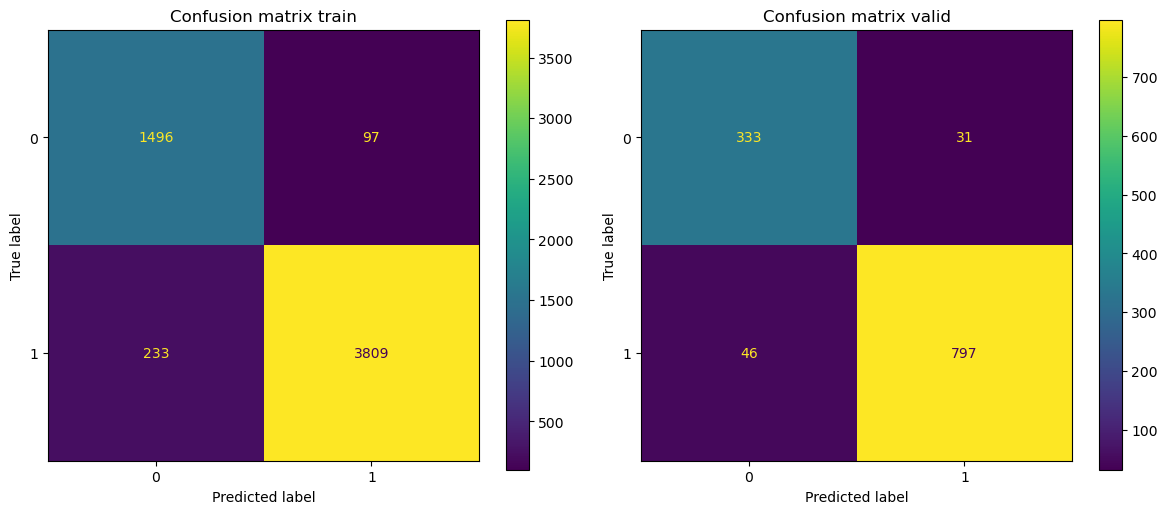

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_tr = LR_cv.predict(scaled_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, display_labels=LR_cv.classes_, ax = axes[0]) # classes_ tira fuori i nomi delle classi
axes[0].set_title('Confusion matrix train')

y_pred_va = LR_cv.predict(scaled_X_valid)
metrics.ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_va, display_labels=LR_cv.classes_, ax = axes[1])
axes[1].set_title('Confusion matrix valid')

plt.tight_layout()
plt.show()

Non sembra ci sia overfitting: rendendo l'insieme circa 5 volte più grande, i termini della matrice di confusione quintuplicano

### Valutiamo velocemente la performance del modello sul valid

In [9]:
fs.get_performance_param(LR_cv, scaled_X_valid, y_valid)

Accuratezza: 0.93621
Precisione: 0.96256
Recall: 0.94543
F1 score: 0.95392
MCC: 0.85067


Comunque il modello sembra funzionare abbastanza bene già così. Proviamo ad ottimizzare anche il threshold

### Ottimizzazione del threshold
Cominciamo disegnando la ROC e la curva Precision-Recall

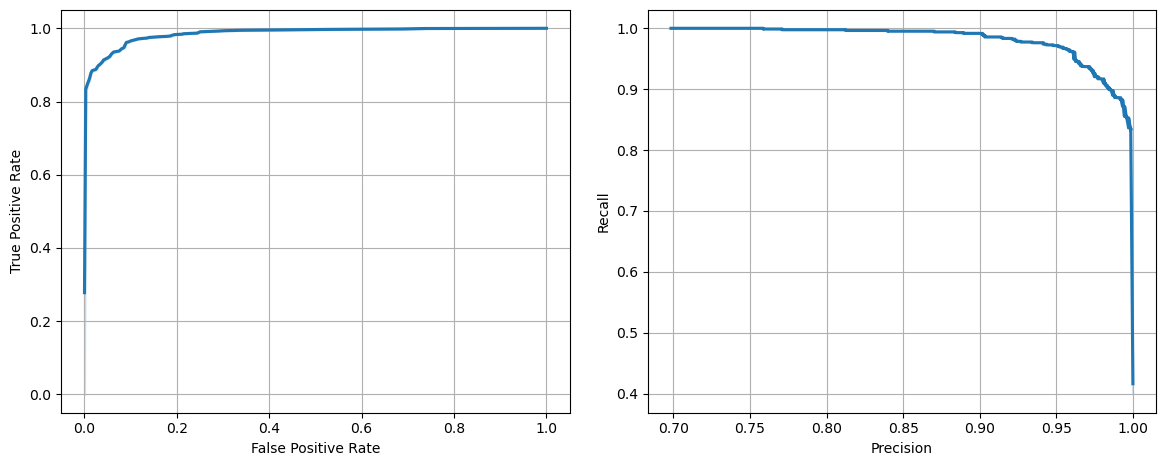

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_va = LR_cv.predict_proba(scaled_X_valid)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC

sns.set_context('talk')

# parametri per la curva ROC
fpr,tpr,thr = metrics.roc_curve(y_valid,y_proba_va)

ax0 = axes[0]
sns.lineplot(x=fpr, y=tpr, ax=ax0)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.grid()

# parametri per la curva Precision-Recall
prec,rec,thr = metrics.precision_recall_curve(y_valid,y_proba_va)

ax1 = axes[1]
sns.lineplot(x=prec, y=rec, ax=ax1)
ax1.set_xlabel('Precision')
ax1.set_ylabel('Recall')
ax1.grid()

plt.tight_layout()

Separiamo Precision e Recall in funzione del threshold

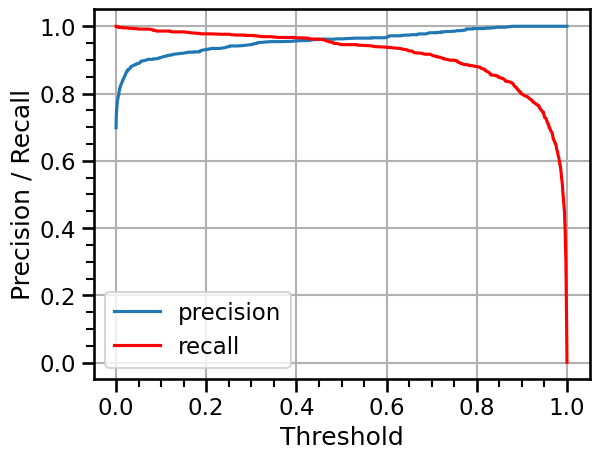

In [11]:
ax = sns.lineplot(x=thr, y=prec[:-1], label='precision')
sns.lineplot(x=thr,y=rec[:-1],label='recall',color='red', ax=ax)
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision / Recall')
ax.minorticks_on()
ax.grid(visible= True)

Come aspettato, la precision = TP / PP aumenta all'aumentare del threshold, andando a 1 per il threshold che diventa 1:\
per thr -> 1, TP -> 0 e PP -> 0 => prec -> 1, per thr -> 0, TP -> AP e PP -> n => prec -> AP / n, è ≠ 0.5 se le classi sono sbilanciate

Al contrario, il recall = TP / AP diminuisce all'aumentare del threshold:\
per thr -> 1, TP -> 0 e AP = const => rec -> 0, per thr -> 0, TP -> AP => rec -> 1

Possiamo scegliere il threshold in diversi modi:
1. non volendo assegnare costi diversi ad una classe rispetto all'altra, una retta a pari performance (cioè a pari costo) nel grafico della ROC è una retta con coefficiente angolare P(N) / P(P) = #N / #P. In questa ottica, il threshold migliore è quindi il threshold che massimizza l'intercetta di questa retta (punto in cui la retta è tangente);

2. guardando online, un altro metro di scelta basato sulla ROC è la statistica J di Youden (si veda https://en.wikipedia.org/wiki/Youden%27s_J_statistic). In pratica il punto con migliore threshold è il punto che massimizza il valore J = sensitivity + specificity - 1 = TPR - FPR;

3. si può scegliere il threshold come punto di intersezione tra Precision e Recall. In questo modo non preferiamo una curva all'altra;

4. studiando il F1-score, si può scegliere il threshold che massimizza questo parametro, anche se questo è più adatto ai contesti in cui ci interessano particolarmente i positivi;

5. studiando il Matthews Correlation Coefficient (MCC), si può scegliere il threshold che massimizza questo parametro. In generale, questo studio è particolarmente adatto allo studio di classi sbilanciate, che è proprio il nostro caso.

Dopo aver comparato sull'insieme di validazione i diversi threshold ottenuti in questo modo, rialleniamo il modello e passiamo finalmente alla valutazione della predittività del modello sull'insieme di test.

In [12]:
y_proba_va = LR_cv.predict_proba(scaled_X_valid)[:, 1]

# 1. Intercetta
num_P = y_valid.sum()
num_N = len(y_valid) - num_P

fpr,tpr,thr_roc = metrics.roc_curve(y_valid,y_proba_va)

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr_int = thr_roc[best_idx]
print(f'Threshold metodo intercetta: {best_thr_int:.5f}')

# 2. statistica J di Youden
J_score = tpr[:-1] - fpr[:-1]

best_idx = np.argmax(J_score)
best_thr_J = thr_roc[best_idx]
print(f'Threshold statistica J di Youden: {best_thr_J:.5f}')

# 3. intersezione Precision-Recall
prec,rec,thr_pre = metrics.precision_recall_curve(y_valid,y_proba_va)

best_idx = np.argmin(np.abs(prec[:-1] - rec[:-1]))
best_thr_PR = thr_pre[best_idx]
print(f'Threshold intersezione Precision-Recall: {best_thr_PR:.5f}')

# 4. F1-score
f1_score = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
best_idx = np.argmax(f1_score)
best_thr_f1 = thr_pre[best_idx]
print(f'Threshold F1-score: {best_thr_f1:.5f}')

thr = np.linspace(0, 1, int(1e3))

# 5. MCC
max_MCC_score = -1
best_thr_MCC = None

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr_MCC = t


print(f'Threshold MCC: {best_thr_MCC:.5f}')

Threshold metodo intercetta: 0.45794
Threshold statistica J di Youden: 0.69587
Threshold intersezione Precision-Recall: 0.45080
Threshold F1-score: 0.34468
Threshold MCC: 0.45145


Si può notare come l'unico threshold sensibilmente diverso sia quello della statistica J di Youden. Questo è un risultato positivo, in quanto una grande differenza tra i parametri sarebbe sintomo di una bassa stabilità del modello. Inoltre, il parametro di Youden, l'unico veramente diverso, è poco appropriato per descrivere classi sbilanciate, per cui è poco significativo in questo contesto.

Nel nostro caso, siccome le nostre classi non sono ben bilanciate e poiché non abbiamo preferenze tra falsi positivi e falsi negativi, scegliamo il coefficiente di correlazione di Matthews come metrica che produce il threshold migliore.

### Retrain su train + valid e studio di test

In [13]:
# uniamo train e valid
X_train_valid = pd.concat([X_train, X_valid], ignore_index=True)
y_train_valid = pd.concat([y_train, y_valid], ignore_index=True)

# riscaliamo le feature numeriche
station_cols = [col for col in X_train.columns if col.startswith('station_')]
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] + station_cols
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train_valid = scaler.fit_transform(X_train_valid[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train_valid = X_train_valid.copy()
scaled_X_test = X_test.copy()

scaled_X_train_valid[num_features] = scaled_num_X_train_valid
scaled_X_test[num_features] = scaled_num_X_test

In [14]:
# alleniamo il modello sul nostro insieme di training
LR_cv.fit(scaled_X_train_valid, y_train_valid)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for t

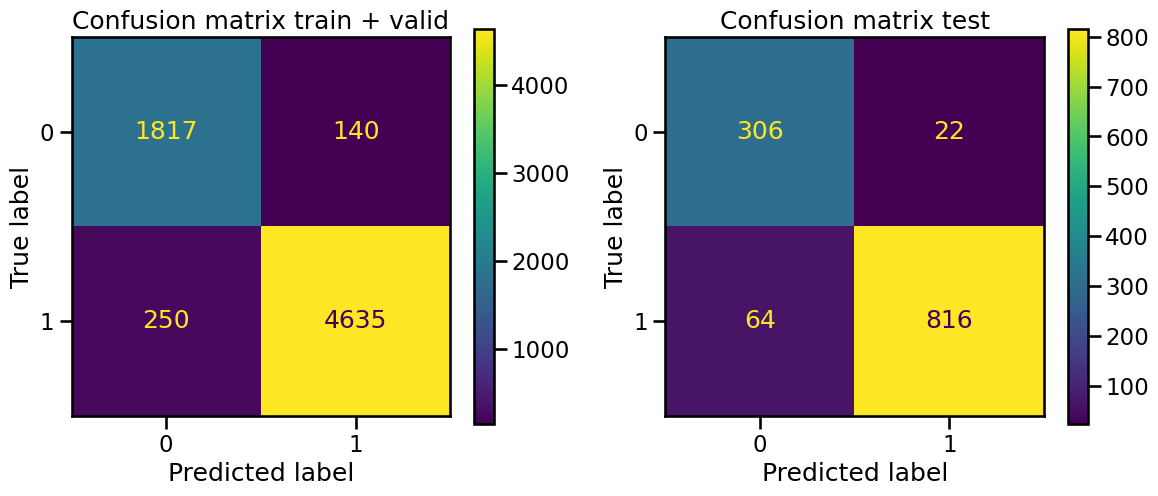

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_tr_va = LR_cv.predict_proba(scaled_X_train_valid)[:, 1]
y_pred_tr_va = (y_proba_tr_va >= best_thr_MCC).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(y_train_valid, y_pred_tr_va, display_labels=LR_cv.classes_, ax = axes[0])
axes[0].set_title('Confusion matrix train + valid')

y_proba_te = LR_cv.predict_proba(scaled_X_test)[:, 1]
y_pred_te = (y_proba_te >= best_thr_MCC).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_te, display_labels=LR_cv.classes_, ax = axes[1])
axes[1].set_title('Confusion matrix test')

plt.tight_layout()
plt.show()

In [17]:
fs.get_performance_param(LR_cv, scaled_X_test, y_test, thr=best_thr_MCC)

Accuratezza: 0.92881
Precisione: 0.97375
Recall: 0.92727
F1 score: 0.94994
MCC: 0.82996


In [ ]:
df_coef = pd.DataFrame(logreg.coef_.T,columns=['coefficients_1', 'coefficients_2', 'coefficients_3', 'coefficients_4', 'coefficients_5'],index=classification_features)
df_coef.plot.barh(figsize=(9,7))

NameError: name 'logreg' is not defined

In [ ]:
y_pred = logreg.predict(scaled_test)
conf_mat  = confusion_matrix(test['target'], y_pred)
ConfusionMatrixDisplay(conf_mat, display_labels=logreg.classes_)
plt.show()

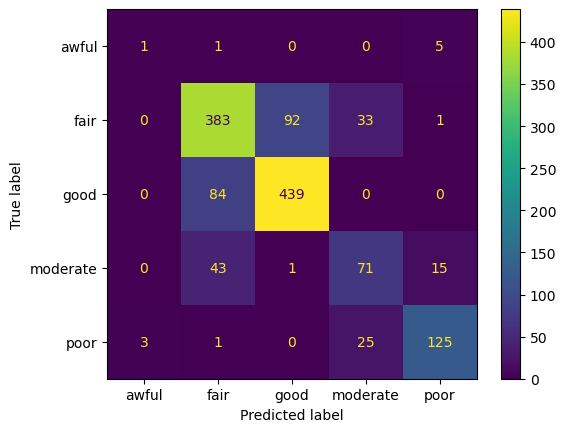

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    test['target'],
    y_pred,
    display_labels=logreg.classes_
)

plt.show()

# Per facilità di studio, rifacciamo il conto con solamente due classi

In [ ]:
map2d = {'good': 'ok', 'fair': 'ok', 'moderate': 'ok', 'poor': 'not ok', 'awful': 'not ok'}
classification_df['target'] = classification_df['target'].map(map2d)

classification_df.head()



,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,ok
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,ok
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,ok
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,ok


In [ ]:
# creo train, valid e test
feature_cols = classification_df.columns.difference(['target'])
X_train, X_test, y_train, y_test= train_test_split(classification_df[feature_cols], classification_df['target'], test_size=0.2, random_state=12)

# riscalo mettendo la media a 0 e la deviazione std a 1
non_num_features = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                    'Rovereto', 'Via Bolzano']
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features] = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,Borgo Valsugana,Monte Gaza,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,...,precipitation_6,precipitation_7,sabato,temperature_1,temperature_2,temperature_3,tot_area_power_1,tot_area_power_2,tot_area_power_3,venerdì
4481,-0.494027,-0.508842,-0.635002,False,False,0.531191,0.502242,-0.068977,-0.668280,-0.624365,...,-0.203446,-0.204153,False,0.884977,1.070297,1.234716,0.261968,0.291952,0.317567,False
762,0.725489,0.947257,1.820469,True,False,-0.166898,-0.101756,-0.005424,0.856459,1.159965,...,-0.203446,-0.204153,False,-1.682592,-1.663495,-1.574727,-0.542594,-0.545691,-0.550840,False
2129,-0.666944,-0.690855,-0.580436,False,True,-1.245763,-1.246173,-1.244710,-1.001817,-1.010166,...,-0.203446,-0.204153,False,0.178306,-0.060927,-0.299854,-1.316289,-1.316471,-1.316610,False
5097,-0.694246,-0.363232,-0.034776,False,False,0.023490,0.247927,0.630107,-0.382392,-0.190339,...,-0.203446,-0.204153,False,0.508086,0.339715,-0.252636,0.450001,0.445460,0.441900,False
1208,1.817594,1.820917,1.820469,True,False,-0.325555,-0.292492,-0.259637,1.332940,1.256415,...,-0.203446,-0.204153,False,0.248973,0.221879,0.219539,-0.770440,-0.767931,-0.767515,False


In [ ]:
# inizializziamo il classificatore
LR_cv = LogisticRegressionCV(
    Cs=10,                              # numero di C = 1/lambda testati
    cv=5,                               # cv = n => n-fold cross validation
    solver='saga',                      # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],    # ratei tra l1 e l2 da testare
    scoring="accuracy",                 # scegliamo di basare la nostra ottimizzazione sull'accuratezza del modello
    max_iter=1000,                      # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                        # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced'             # bilancia in automatico le classi in base alla frequenza di input
)

In [ ]:
# alleniamo il modello sul nostro insieme di training

LR_cv.fit(scaled_X_train,y_train)

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0, 0.25, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for th

<Axes: >

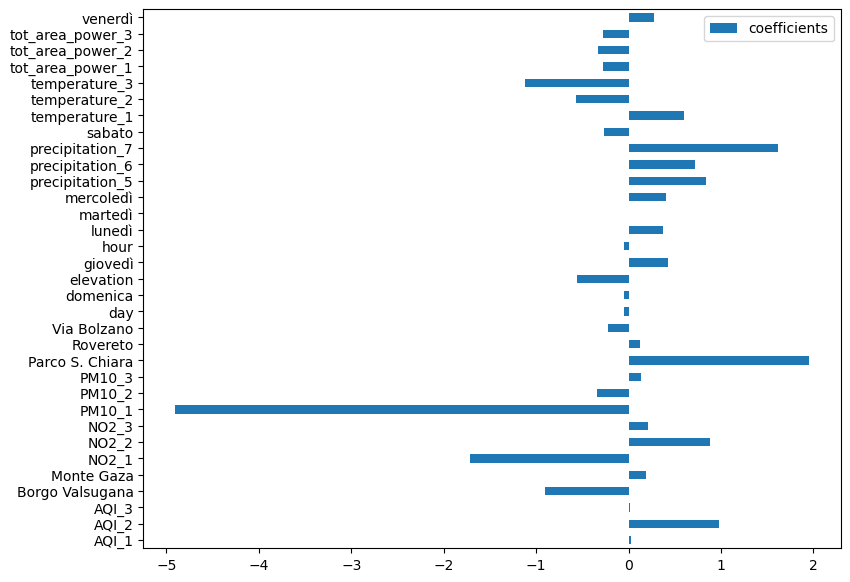

In [ ]:
# diamo un'occhiata ai pesi per ciascuna feature in modo da capire quali siano le feature importanti e quali invece quelle inutili
coefs_df = pd.DataFrame(LR_cv.coef_.T,columns=['coefficients'],index=feature_cols)
coefs_df.plot.barh(figsize=(9,7))

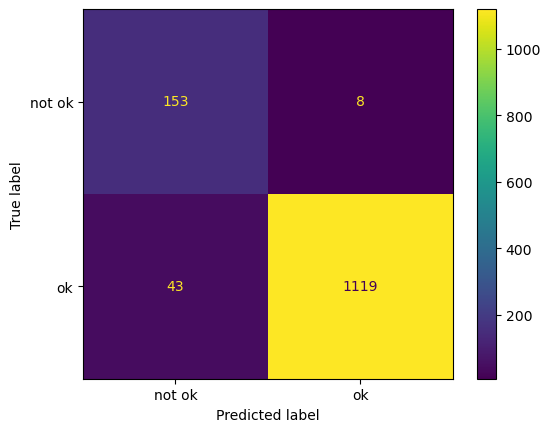

In [ ]:
# disegnamo la confusion matrix in modo da capire se il nostro modello funziona o no
y_pred = LR_cv.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=LR_cv.classes_ # tira fuori i nomi delle classi
)

plt.show()

0.22923054682380614


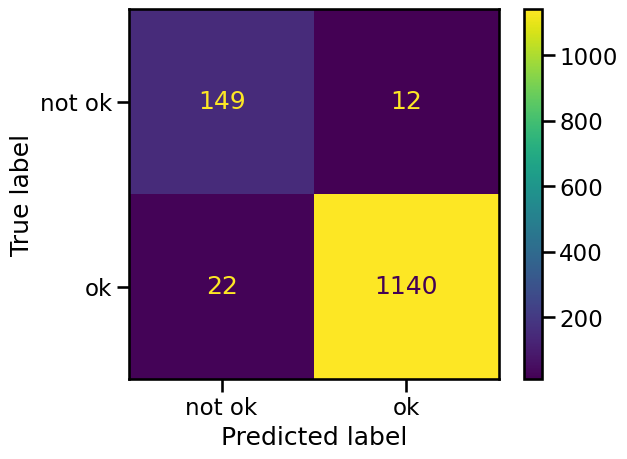

In [ ]:
# 1)
num_N = (y_test == 'not ok').sum()
num_P = (y_test == 'ok').sum()

y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC
fpr,tpr,thr = metrics.roc_curve(y_test,y_proba,pos_label='ok')

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.1313145823033542


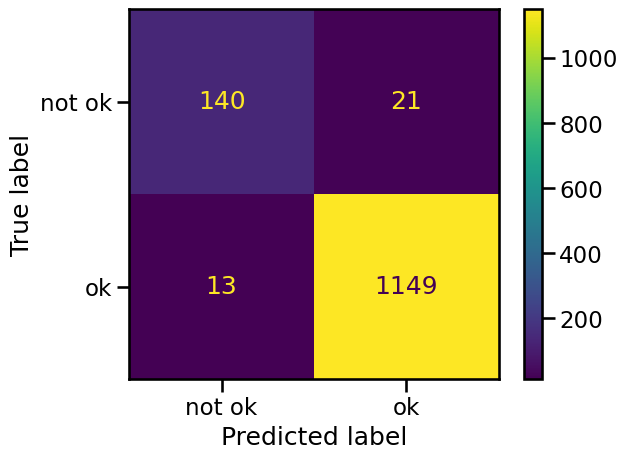

In [ ]:
# 2)
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
f1_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    f1_score.append(2 * tp / (2 * tp + fp + fn))

best_idx = np.argmax(f1_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()

0.22923054682380614


/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))
/var/folders/kk/q9vd_8nn5w5cp7fcpz9zs4sh0000gn/T/ipykernel_12621/1914224085.py:10: RuntimeWarning: invalid value encountered in scalar divide
  MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))


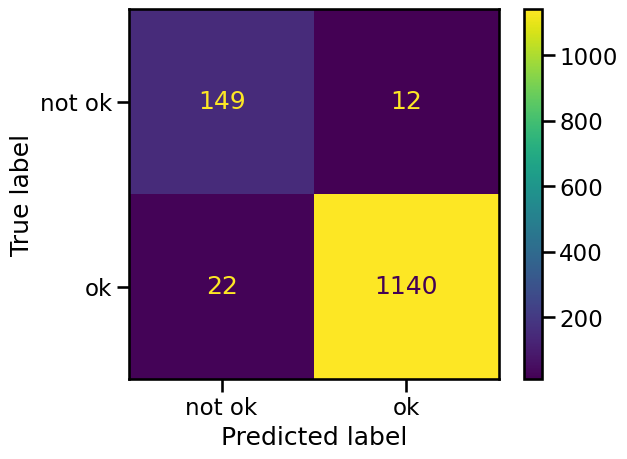

In [ ]:
y_proba = LR_cv.predict_proba(scaled_X_test)[:, 1]
MCC_score = []
for t in thr:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = metrics.confusion_matrix((y_test == 'ok').astype(int), y_pred,).ravel()
    pp = tp + fp
    pn = tn + fn
    ap = tp + fn
    an = tn + fp
    MCC_score.append((tp * tn - fp * fn) / np.sqrt(pp * pn * ap * an))

best_idx = np.nanargmax(MCC_score)
best_thr = thr[best_idx]
print(best_thr)

y_pred = (y_proba >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(
    (y_test == 'ok').astype(int),
    y_pred,
    display_labels=['not ok', 'ok'] # tira fuori i nomi delle classi
)

plt.show()